## EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/tanaphan/Downloads/panel.csv")
df_og = df.copy()
df.shape

/var/folders/ht/5y_rw30x03sgygff528jxrm00000gn/T/ipykernel_7756/2850428029.py:5: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/tanaphan/Downloads/panel.csv")


(468512, 15)

In [46]:
df.head()

,com_num,name,T,week,age_years,sector,region,account_type,accounts_overdue,prior_nonlloyds_charges,tone_z,vol_z,z_source,media_missing,label
0,15073164,NFLECTION ADVISORY LIMITED,2024-10-13,2024-10-13,1.163587,M: Professional/Scientific,East of England,total-exemption-full,False,0,0.542254,-1.433781,cell,0,0
1,13522064,NFOGENIE LTD,2024-10-13,2024-10-13,3.230664,J: Information/Comms,London,micro-entity,False,0,0.767893,-0.200684,cell,0,0
2,11006939,NNOV8 LIMITED,2024-10-13,2024-10-13,7.006160,J: Information/Comms,South East,micro-entity,False,0,0.796996,-0.602194,cell,0,0
3,SC606050,NSPIRED INVESTMENTS LTD,2024-10-13,2024-10-13,6.143737,L: Real Estate,Scotland,total-exemption-full,False,5,2.781579,-1.133702,cell,0,0
4,11303802,"""1ST RATE"" PSYCHOLOGY SERVICES LTD",2024-10-13,2024-10-13,6.507871,P: Education,East of England,micro-entity,False,0,0.864810,-0.661024,cell,0,0


In [47]:
df[df.columns[8]].apply(type).value_counts()

accounts_overdue
<class 'str'>     402976
<class 'bool'>     65536
Name: count, dtype: int64

In [48]:
df.dtypes

com_num                     object
name                        object
T                           object
week                        object
age_years                  float64
sector                      object
region                      object
account_type                object
accounts_overdue            object
prior_nonlloyds_charges      int64
tone_z                     float64
vol_z                      float64
z_source                    object
media_missing                int64
label                        int64
dtype: object

In [49]:
df.isnull().sum()

com_num                        0
name                           0
T                              0
week                           0
age_years                      0
sector                        14
region                       853
account_type                   0
accounts_overdue               0
prior_nonlloyds_charges        0
tone_z                     31459
vol_z                      31031
z_source                   31031
media_missing                  0
label                          0
dtype: int64

### Check missing values: "media_missing", "tone_z", and "vol_z"

In [50]:
df["media_missing"].value_counts()

media_missing
0    437053
1     31459
Name: count, dtype: int64

In [51]:
tone_missing = df["tone_z"].isnull()
vol_missing = df["vol_z"].isnull()

print((df["media_missing"] == tone_missing).all())
print((df["media_missing"] == vol_missing).all())

True
False


In [52]:
print("vol_z missing, tone_z NOT:", (vol_missing & ~tone_missing).sum())
print("tone_z missing, vol_z NOT:", (tone_missing & ~vol_missing).sum())
print("Both missing :", (tone_missing & vol_missing).sum())

vol_z missing, tone_z NOT: 0
tone_z missing, vol_z NOT: 428
Both missing : 31031


This means if "vol_z" is NaN --> "tone_z" will always be NaN, but not vice versa

In [53]:
df["z_source"].value_counts()

z_source
cell               288689
sector-fallback    148792
Name: count, dtype: int64

### Check "Label"

In [54]:
df["label"].value_counts()

label
0    468396
1       116
Name: count, dtype: int64

In [55]:
df["label"].value_counts(normalize=True) * 100

label
0    99.975241
1     0.024759
Name: proportion, dtype: float64

In [56]:
df[df["label"] == 1].groupby("T").size()

T
2024-10-13    12
2025-01-12    14
2025-04-13     9
2025-07-13    10
2025-10-12    22
2026-01-11    26
2026-04-12    23
dtype: int64

In [57]:
Timeframes = sorted(df["T"].unique())

t1_5 = df[df["T"].isin(Timeframes[:5])]
t6_7 = df[df["T"].isin(Timeframes[5:])]

print(f"T1-5: {len(t1_5)} ({len(t1_5)/len(df)*100:.2f}%)")
print(f"T6-7: {len(t6_7)} ({len(t6_7)/len(df)*100:.2f}%)")


T1-5: 334346 (71.36%)
T6-7: 134166 (28.64%)


In [58]:
t1_5_lloyds = (t1_5["label"]==1).sum()
t6_7_lloyds = (t6_7["label"]==1).sum()
print(f"T1-5: {t1_5_lloyds} ({t1_5_lloyds/(t1_5_lloyds+t6_7_lloyds)*100:.4f}%)")
print(f"T6-7: {t6_7_lloyds} ({t6_7_lloyds/(t1_5_lloyds+t6_7_lloyds)*100:.4f}%)")

T1-5: 67 (57.7586%)
T6-7: 49 (42.2414%)


### Check Unique Values


In [59]:
df.nunique()

com_num                    67164
name                       67164
T                              7
week                           7
age_years                  18281
sector                        21
region                        12
account_type                   5
accounts_overdue               5
prior_nonlloyds_charges       78
tone_z                       924
vol_z                        927
z_source                       2
media_missing                  2
label                          2
dtype: int64

In [60]:
df["accounts_overdue"].unique()

array(['False', 'True', 'unknown', False, True], dtype=object)

NOTE:
- EXTREME CLASS IMBALANCE 0.024759% and 99.975241%
- Identifier cols: "com_num", "name"
- Category Cols: "sector", "region", "account_type"
- Target col: "label"
- The number of missing value in "tone_z" is exactly the same as in "media_missing"
- "media_missing" indicates missing values in "tone_z", NOT "vol_z"
- 0 in a z-score has meaning, so filling missing values with "0" in "tone_z" and "vol_z" might impact the model?
- Train/Test split by Timeframe --> Timeframe 1-5 = Train, Timeframe 6-7 = Test



CLEAN:
- Drop "week"
- Drop "z_source"
- Drop rows with missing "region", "sector", "accounts_overdue"
- Change 5 diff unique values in "account_overdue" --> int 0/1
- Fill missing value with 0 in "tone_z" as we already have "missing_media" column
- Create a new flag column "vol_missing" for "vol_z"
- Fill missing value with 0 in "vol_z"



## CLEANING

In [61]:
# Drop unused columns + rows with missing "sector"
df= df.drop(columns=["week", "z_source"])
df = df.dropna(subset=["sector"])

#### Note: I found that dropping rows with missing "region" value removes 1 positive-class data (name "1916 HOLDINGS LIMITED" | com_num "15832841"). Since we have very limited data, I think it is better to impute rather than drop

In [62]:
# Mode imputation
mode_region = df["region"].mode()[0]
df["region"] = df["region"].fillna(mode_region)

In [63]:
# Change values in "accounts_overdue" to Boolean
accounts_overdue_map = {
    "True": True, 
    True: True,
    "False": False, 
    False: False,
    "unknown": np.nan,
}

df["accounts_overdue"] = df["accounts_overdue"].map(accounts_overdue_map)
df["accounts_overdue"].value_counts(dropna=False)


accounts_overdue
False    461603
True       6888
NaN           7
Name: count, dtype: int64

In [64]:
# Drop rows with missing "accounts_overdue"
df = df.dropna(subset=["accounts_overdue"])

# Change data type to int
df["accounts_overdue"] = df["accounts_overdue"].astype(int)

In [65]:
# Create a new column "vol_missing"
df["vol_missing"] = df["vol_z"].isnull().astype(int)

# fill missing values with "0"
df["tone_z"] = df["tone_z"].fillna(0)
df["vol_z"] = df["vol_z"].fillna(0)

In [66]:
df.isnull().sum()

com_num                    0
name                       0
T                          0
age_years                  0
sector                     0
region                     0
account_type               0
accounts_overdue           0
prior_nonlloyds_charges    0
tone_z                     0
vol_z                      0
media_missing              0
label                      0
vol_missing                0
dtype: int64

In [67]:
df.head()

,com_num,name,T,age_years,sector,region,account_type,accounts_overdue,prior_nonlloyds_charges,tone_z,vol_z,media_missing,label,vol_missing
0,15073164,NFLECTION ADVISORY LIMITED,2024-10-13,1.163587,M: Professional/Scientific,East of England,total-exemption-full,0,0,0.542254,-1.433781,0,0,0
1,13522064,NFOGENIE LTD,2024-10-13,3.230664,J: Information/Comms,London,micro-entity,0,0,0.767893,-0.200684,0,0,0
2,11006939,NNOV8 LIMITED,2024-10-13,7.006160,J: Information/Comms,South East,micro-entity,0,0,0.796996,-0.602194,0,0,0
3,SC606050,NSPIRED INVESTMENTS LTD,2024-10-13,6.143737,L: Real Estate,Scotland,total-exemption-full,0,5,2.781579,-1.133702,0,0,0
4,11303802,"""1ST RATE"" PSYCHOLOGY SERVICES LTD",2024-10-13,6.507871,P: Education,East of England,micro-entity,0,0,0.864810,-0.661024,0,0,0


In [68]:
Timeframes = sorted(df["T"].unique())

t1_5 = df[df["T"].isin(Timeframes[:5])]
t6_7 = df[df["T"].isin(Timeframes[5:])]

print(f"T1-5: {len(t1_5)} ({len(t1_5)/len(df)*100:.2f}%)")
print(f"T6-7: {len(t6_7)} ({len(t6_7)/len(df)*100:.2f}%)")

T1-5: 334331 (71.36%)
T6-7: 134160 (28.64%)


In [69]:
t1_5_lloyds = (t1_5["label"]==1).sum()
t6_7_lloyds = (t6_7["label"]==1).sum()
print(f"T1-5: {t1_5_lloyds} ({t1_5_lloyds/(t1_5_lloyds+t6_7_lloyds)*100:.4f}%)")
print(f"T6-7: {t6_7_lloyds} ({t6_7_lloyds/(t1_5_lloyds+t6_7_lloyds)*100:.4f}%)")

T1-5: 67 (57.7586%)
T6-7: 49 (42.2414%)


In [70]:
# Check which company was removed

# not_clean = df_og[df_og["label"]==1]["com_num"]
# cleaned = df[df["label"]==1]["com_num"]

# missing_com = set(not_clean) - set(cleaned)
# print(missing_com)

In [71]:
# df_og[df_og["com_num"] == "15832841"]

Summary:

- "week" and "z_source" dropped
- rows missing "sector" dropped
- Mode-imputed "region"
- "accounts_overdue" --> "unknown" rows dropped + converted to Boolean(int 0/1)
- missing values in "tone_z" and "vol_z" filled with 0
- add column "vol_missing"

In [72]:
#df.to_csv("panel_cleaned.csv", index=False)

## MODELING

In [73]:
df.dtypes

com_num                     object
name                        object
T                           object
age_years                  float64
sector                      object
region                      object
account_type                object
accounts_overdue             int64
prior_nonlloyds_charges      int64
tone_z                     float64
vol_z                      float64
media_missing                int64
label                        int64
vol_missing                  int64
dtype: object

In [74]:
num_cols = ["age_years", "prior_nonlloyds_charges", "tone_z", "vol_z"]
cat_cols = ["sector", "region", "account_type"]
bool_cols = ["accounts_overdue", "media_missing", "vol_missing"]
target_col = "label"

feature_cols = cat_cols + num_cols + bool_cols
feature_cols

['sector',
 'region',
 'account_type',
 'age_years',
 'prior_nonlloyds_charges',
 'tone_z',
 'vol_z',
 'accounts_overdue',
 'media_missing',
 'vol_missing']

In [75]:
Timeframes = sorted(df["T"].unique())

train_df = df[df["T"].isin(Timeframes[:5])] # T1-5 = Train set
test_df = df[df["T"].isin(Timeframes[5:])] # T6-7 = Test set

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

### Logistic Regression

In [76]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

RS = 42

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
], remainder="passthrough")

model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RS)

pipe_lr = Pipeline([
    ("prep", preprocess),
    ("clf", model)
])

pipe_lr.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [77]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, average_precision_score, precision_recall_curve, roc_curve

y_pred_lr = pipe_lr.predict(X_test)

print(classification_report(y_test, y_pred_lr, target_names=["NOT Lloyds Customer", "Lloyds Customer"]))

                     precision    recall  f1-score   support

NOT Lloyds Customer       1.00      0.80      0.89    134111
    Lloyds Customer       0.00      0.63      0.00        49

           accuracy                           0.80    134160
          macro avg       0.50      0.72      0.45    134160
       weighted avg       1.00      0.80      0.89    134160



In [78]:
confusion_matrix(y_test, y_pred_lr)

array([[107733,  26378],
       [    18,     31]])

In [79]:
y_proba_lr = pipe_lr.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, y_proba_lr)
print(f"ROC-AUC: {auc_lr}")

ROC-AUC: 0.7322978270056224


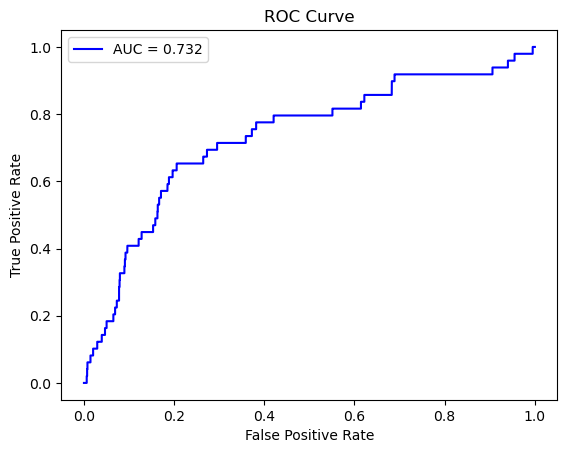

In [80]:
fpr, tpr, _ = roc_curve(y_test, y_proba_lr)
plt.plot(fpr, tpr, color="blue", label=f"AUC = {auc_lr:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [81]:
ap_lr = average_precision_score(y_test, y_proba_lr)
print(f"Average Precision: {ap_lr}")

Average Precision: 0.0011211718845379583


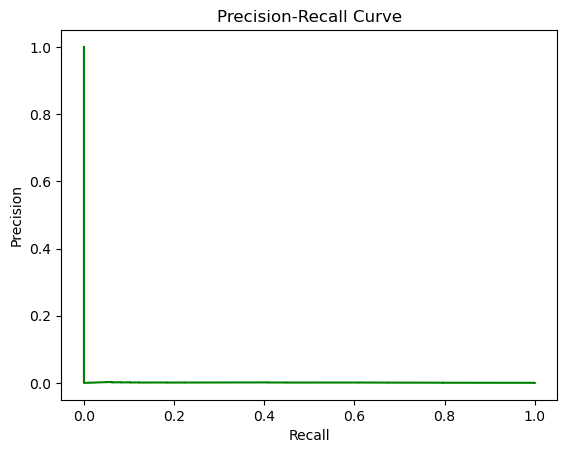

In [82]:
prec, rec, _ = precision_recall_curve(y_test, y_proba_lr)
plt.plot(rec, prec, color="green")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

### Random Forest

In [83]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced", random_state=RS)

pipe_rf = Pipeline([
    ("prep", preprocess),
    ("clf_rf", model_rf)
])

pipe_rf.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf_rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [84]:
y_pred_rf = pipe_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf, target_names=["NOT Lloyds Customer", "Lloyds Customer"]))

                     precision    recall  f1-score   support

NOT Lloyds Customer       1.00      0.90      0.95    134111
    Lloyds Customer       0.00      0.43      0.00        49

           accuracy                           0.90    134160
          macro avg       0.50      0.67      0.48    134160
       weighted avg       1.00      0.90      0.95    134160



In [85]:
confusion_matrix(y_test, y_pred_rf)

array([[121141,  12970],
       [    28,     21]])

In [86]:
y_proba_rf = pipe_rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"ROC-AUC: {auc_rf}")

ROC-AUC: 0.7658133172962573


In [87]:
ap_rf = average_precision_score(y_test, y_proba_rf)
print(f"Average Precision: {ap_rf}")

Average Precision: 0.001416200454231664
